# Diamonds Prices — Exploratory Data Analysis
This notebook is structured as an analytical report: context, metrics, interpretation of results, and actionable conclusions.



## Objective
Explore the diamonds dataset, assess data quality, and identify relationships relevant to price in order to guide cleaning, feature engineering, and modelling.



## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2_contingency, kurtosis, skew
from statsmodels.regression.linear_model import RegressionResultsWrapper
from statsmodels.stats.outliers_influence import variance_inflation_factor
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Load

In [2]:
data_path = '../data/raw/DiamondsPrices.csv'
df: pd.DataFrame = pd.read_csv(data_path, index_col=0)
print(f'Dataset shape: {df.shape}')
display(df.head())


Dataset shape: (53943, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.describe()

,carat,depth,table,price,x,y,z
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,0.797935,61.749322,57.457251,3932.734294,5.731158,5.734526,3.538730
std,0.473999,1.432626,2.234549,3989.338447,1.121730,1.142103,0.705679
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 3. Variable Profiling Table
The profiling table provides a quick view of types, cardinality, and potential inconsistencies at the start of the analysis.



In [4]:
def summary_profiling_table(df: pd.DataFrame) -> pd.DataFrame:
    summary = []
    for col in df.columns:
        series = df[col]
        summary.append({
            "variable": col,
            "num_of_values": series.notna().sum(),
            "pct_missing": series.isna().mean() * 100,
            "unique_values": series.nunique(dropna=True),
            "mean": series.mean() if pd.api.types.is_numeric_dtype(series) else np.nan,
            "python_type": str(series.dtype),
            "inferred_type": pd.api.types.infer_dtype(series, skipna=True)
        })
    return (
        pd.DataFrame(summary)
        .sort_values(by=["pct_missing", "unique_values"], ascending=[False, False])
        .reset_index(drop=True)
    )

summary_profiling_table(df)

,variable,num_of_values,pct_missing,unique_values,mean,python_type,inferred_type
0,price,53943,0.0,11602,3932.734294,int64,integer
1,x,53943,0.0,554,5.731158,float64,floating
2,y,53943,0.0,552,5.734526,float64,floating
3,z,53943,0.0,375,3.538730,float64,floating
4,carat,53943,0.0,273,0.797935,float64,floating
5,depth,53943,0.0,184,61.749322,float64,floating
6,table,53943,0.0,127,57.457251,float64,floating
7,clarity,53943,0.0,8,NaN,str,string
8,color,53943,0.0,7,NaN,str,string
9,cut,53943,0.0,5,NaN,str,string


In [5]:
def criar_dicionario_dados(df):
    descricoes = {
        "carat": "Peso do diamante em quilates.",
        "cut": "Qualidade do corte do diamante.",
        "color": "Classificação da cor do diamante (D = melhor, J = pior).",
        "clarity": "Grau de pureza do diamante.",
        "depth": "Profundidade total do diamante em percentagem.",
        "table": "Largura da mesa do diamante em percentagem.",
        "price": "Preço do diamante em dólares americanos.",
        "x": "Comprimento do diamante em milímetros.",
        "y": "Largura do diamante em milímetros.",
        "z": "Profundidade do diamante em milímetros."
    }

    tabela = pd.DataFrame({
        "Variável": df.columns,
        "Tipo de Dados": [str(df[col].dtype) for col in df.columns],
        "Descrição": [descricoes.get(col, "Descrição não disponível.") for col in df.columns]
    })

    return tabela

### Data Dictionary Interpretation
The dictionary reduces ambiguity when reading column names and helps justify the hypotheses tested in subsequent steps.



In [6]:
dicionario = criar_dicionario_dados(df)
dicionario


,Variável,Tipo de Dados,Descrição
0,carat,float64,Peso do diamante em quilates.
1,cut,str,Qualidade do corte do diamante.
2,color,str,"Classificação da cor do diamante (D = melhor, ..."
3,clarity,str,Grau de pureza do diamante.
4,depth,float64,Profundidade total do diamante em percentagem.
5,table,float64,Largura da mesa do diamante em percentagem.
6,price,int64,Preço do diamante em dólares americanos.
7,x,float64,Comprimento do diamante em milímetros.
8,y,float64,Largura do diamante em milímetros.
9,z,float64,Profundidade do diamante em milímetros.


## 4. Numerical Variables Quality Report


In [7]:
def numeric_quality_report(df):
    numeric_df = df.select_dtypes(include=[np.number])
    summary = []
    for col in numeric_df.columns:
        s = numeric_df[col].dropna()
        if len(s) == 0:
            continue
        mean_val = s.mean()
        median_val = s.median()
        std_val = s.std()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        cv = std_val / mean_val if abs(mean_val) > 1e-9 else np.nan
        summary.append({
            "variable": col,
            "n": len(s),
            "mean": mean_val,
            "median": median_val,
            "mean_minus_median": mean_val - median_val,
            "std": std_val,
            "cv": cv,
            "IQR": q3 - q1,
            "skewness": skew(s, bias=False),
            "kurtosis_excess": kurtosis(s, bias=False)
        })
    return (
        pd.DataFrame(summary)
        .sort_values("skewness", key=lambda x: abs(x), ascending=False)
        .reset_index(drop=True)
    )


In [8]:
numeric_report = numeric_quality_report(df)

In [9]:
def interpret_numeric_quality(df_report):
    report = df_report.copy()

    def mean_median_label(x, tol=1e-6):
        if pd.isna(x): return np.nan
        elif abs(x) < tol: return "Mean and median are approximately equal"
        elif x > 0: return "Mean greater than median (suggests positive skew)"
        else: return "Mean lower than median (suggests negative skew)"

    def cv_label(cv):
        if pd.isna(cv): return "CV undefined (mean ≈ 0)"
        elif cv < 0: return "CV negative (mean < 0)"
        elif cv < 0.3: return "Low variability"
        elif cv < 0.7: return "Moderate variability"
        else: return "High variability"

    def skew_label(sk):
        if pd.isna(sk): return np.nan
        abs_sk = abs(sk)
        magnitude = "Approximately symmetric" if abs_sk < 0.5 else ("Moderately skewed" if abs_sk < 1 else "Highly skewed")
        direction = " (positive/right skew)" if sk > 0 else (" (negative/left skew)" if sk < 0 else "")
        return magnitude + direction

    def kurt_label(k):
        if pd.isna(k): return np.nan
        elif k < -1.0: return "Very flat distribution (platykurtic)"
        elif k < -0.5: return "Light tails (mild platykurtic)"
        elif abs(k) <= 0.5: return "Approximately normal tails (mesokurtic)"
        elif k <= 1.0: return "Slightly heavy tails"
        elif k <= 3.0: return "Moderately heavy tails"
        else: return "Heavy tails / extreme values (leptokurtic)"

    report["Mean_vs_median_interpretation"] = report["mean_minus_median"].apply(mean_median_label)
    report["CV_interpretation"] = report["cv"].apply(cv_label)
    report["Skewness_interpretation"] = report["skewness"].apply(skew_label)
    report["Kurtosis_interpretation"] = report["kurtosis_excess"].apply(kurt_label)

    return report[[
        "variable", "n", "mean", "median", "mean_minus_median", "Mean_vs_median_interpretation",
        "std", "cv", "CV_interpretation", "IQR", "skewness", "Skewness_interpretation",
        "kurtosis_excess", "Kurtosis_interpretation"
    ]]



In [10]:
numeric_interpretive = interpret_numeric_quality(numeric_report)
numeric_interpretive

,variable,n,mean,median,mean_minus_median,Mean_vs_median_interpretation,std,cv,CV_interpretation,IQR,skewness,Skewness_interpretation,kurtosis_excess,Kurtosis_interpretation
0,y,53943,5.734526,5.71,0.024526,Mean greater than median (suggests positive skew),1.142103,0.199163,Low variability,1.82,2.434233,Highly skewed (positive/right skew),91.219791,Heavy tails / extreme values (leptokurtic)
1,price,53943,3932.734294,2401.00,1531.734294,Mean greater than median (suggests positive skew),3989.338447,1.014393,High variability,4374.00,1.618476,Highly skewed (positive/right skew),2.178040,Moderately heavy tails
2,z,53943,3.538730,3.53,0.008730,Mean greater than median (suggests positive skew),0.705679,0.199416,Low variability,1.13,1.522481,Highly skewed (positive/right skew),47.089370,Heavy tails / extreme values (leptokurtic)
3,carat,53943,0.797935,0.70,0.097935,Mean greater than median (suggests positive skew),0.473999,0.594032,Moderate variability,0.64,1.116705,Highly skewed (positive/right skew),1.256902,Moderately heavy tails
4,table,53943,57.457251,57.00,0.457251,Mean greater than median (suggests positive skew),2.234549,0.038891,Low variability,3.00,0.796836,Moderately skewed (positive/right skew),2.801180,Moderately heavy tails
5,x,53943,5.731158,5.70,0.031158,Mean greater than median (suggests positive skew),1.121730,0.195725,Low variability,1.83,0.378685,Approximately symmetric (positive/right skew),-0.618030,Light tails (mild platykurtic)
6,depth,53943,61.749322,61.80,-0.050678,Mean lower than median (suggests negative skew),1.432626,0.023201,Low variability,1.50,-0.082187,Approximately symmetric (negative/left skew),5.738874,Heavy tails / extreme values (leptokurtic)


### Interpretation Layer for Numerical Quality
Variables with strong asymmetry or high kurtosis may benefit from transformation, winsorisation, or outlier treatment before modelling.



In [11]:
def overall_data_quality_table(numeric_report):
    results = []

    for _, row in numeric_report.iterrows():
        cv = row["cv"]
        sk = row["skewness"]
        kurt = row["kurtosis_excess"]

        challenges = []
        if cv >= 0.7: challenges.append("High dispersion")
        if abs(sk) >= 1: challenges.append("Strong skewness")
        elif abs(sk) >= 0.5: challenges.append("Moderate skewness")
        if kurt >= 3: challenges.append("Heavy tails")
        elif kurt > 0.5: challenges.append("Moderately heavy tails")

        cv_flag   = False if pd.isna(cv) else (cv >= 0.7)
        sk_flag   = False if pd.isna(sk) else (abs(sk) >= 1)
        kurt_flag = False if pd.isna(kurt) else (kurt >= 3)

        score = cv_flag + sk_flag + kurt_flag

        if score == 0:
            validity = "Well-behaved for linear modeling"
        elif score == 1:
            validity = "Minor distributional issues"
        elif score == 2:
            validity = "Moderate distributional risk"
        else:
            validity = "High distributional risk"

        results.append({
            "variable": row["variable"],
            "validity_assessment": validity,
            "modeling_assessment": ", ".join(challenges) if challenges else "Statistically well-behaved",
            "overall_quality": {
                0: "High Quality",
                1: "Moderate Quality",
                2: "Statistically Challenging",
                3: "Statistically Challenging"
            }.get(score, "Statistically Challenging")
        })

    return pd.DataFrame(results)


overall_data_quality_table(numeric_report)

,variable,validity_assessment,modeling_assessment,overall_quality
0,y,Moderate distributional risk,"Strong skewness, Heavy tails",Statistically Challenging
1,price,Moderate distributional risk,"High dispersion, Strong skewness, Moderately h...",Statistically Challenging
2,z,Moderate distributional risk,"Strong skewness, Heavy tails",Statistically Challenging
3,carat,Minor distributional issues,"Strong skewness, Moderately heavy tails",Moderate Quality
4,table,Well-behaved for linear modeling,"Moderate skewness, Moderately heavy tails",High Quality
5,x,Well-behaved for linear modeling,Statistically well-behaved,High Quality
6,depth,Minor distributional issues,Heavy tails,Moderate Quality


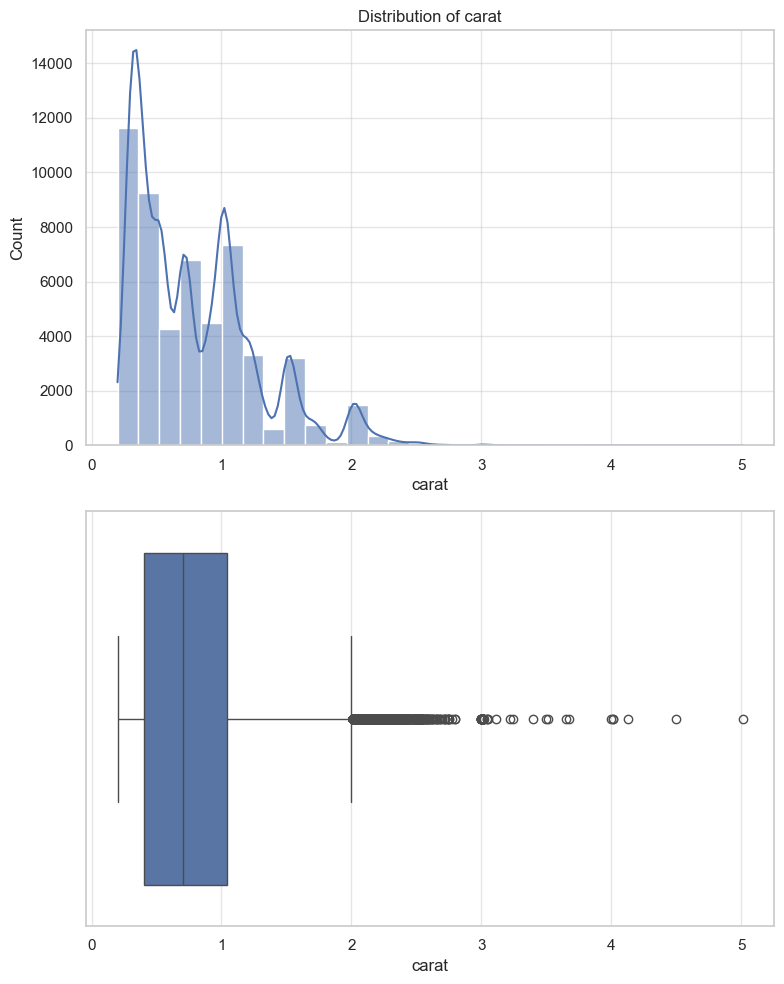

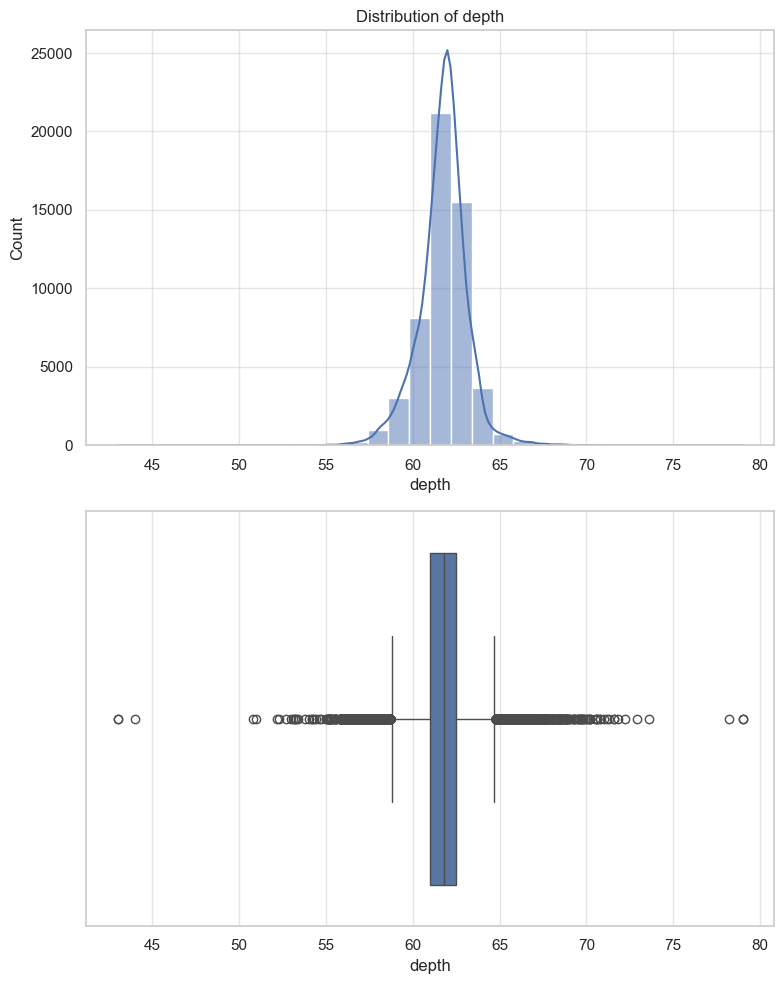

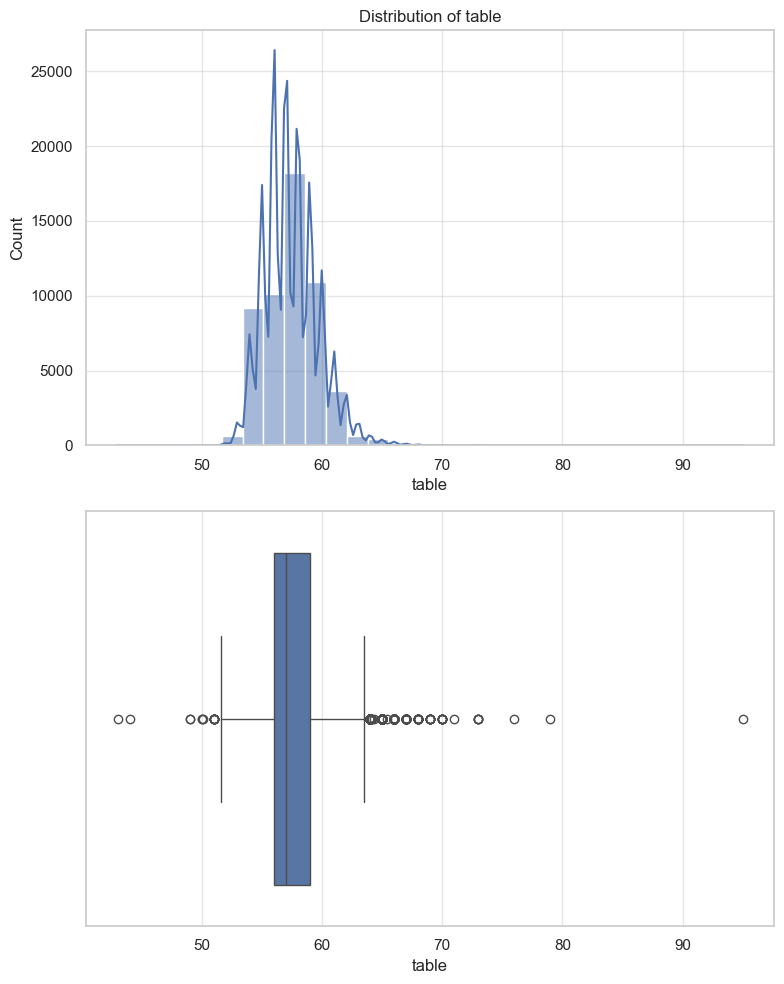

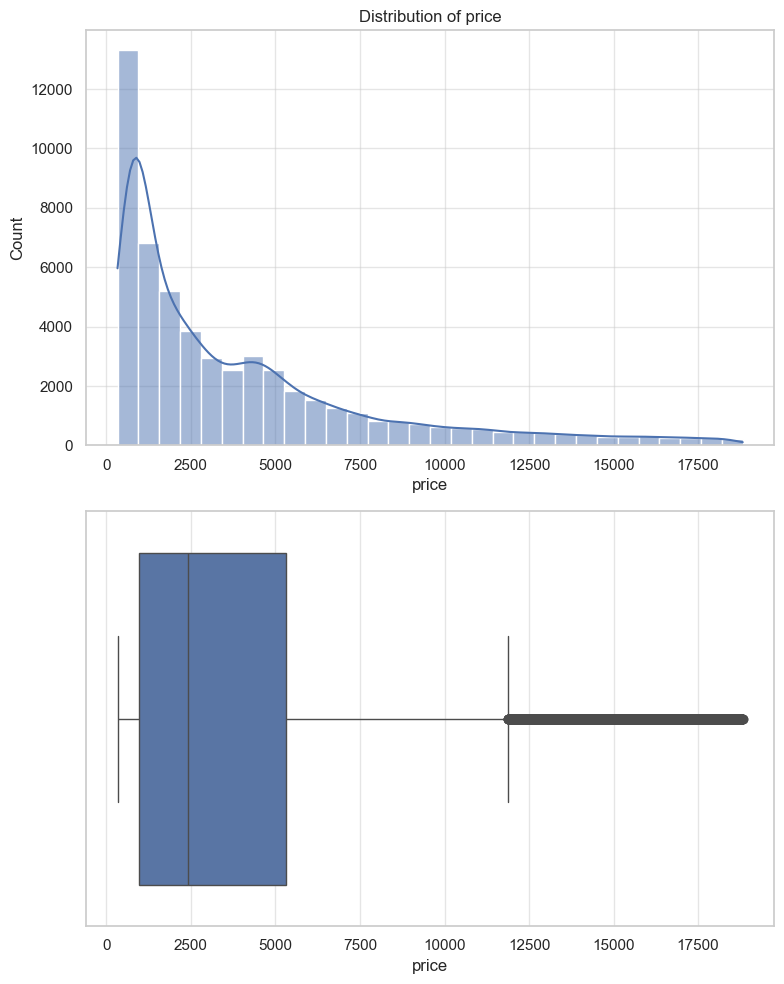

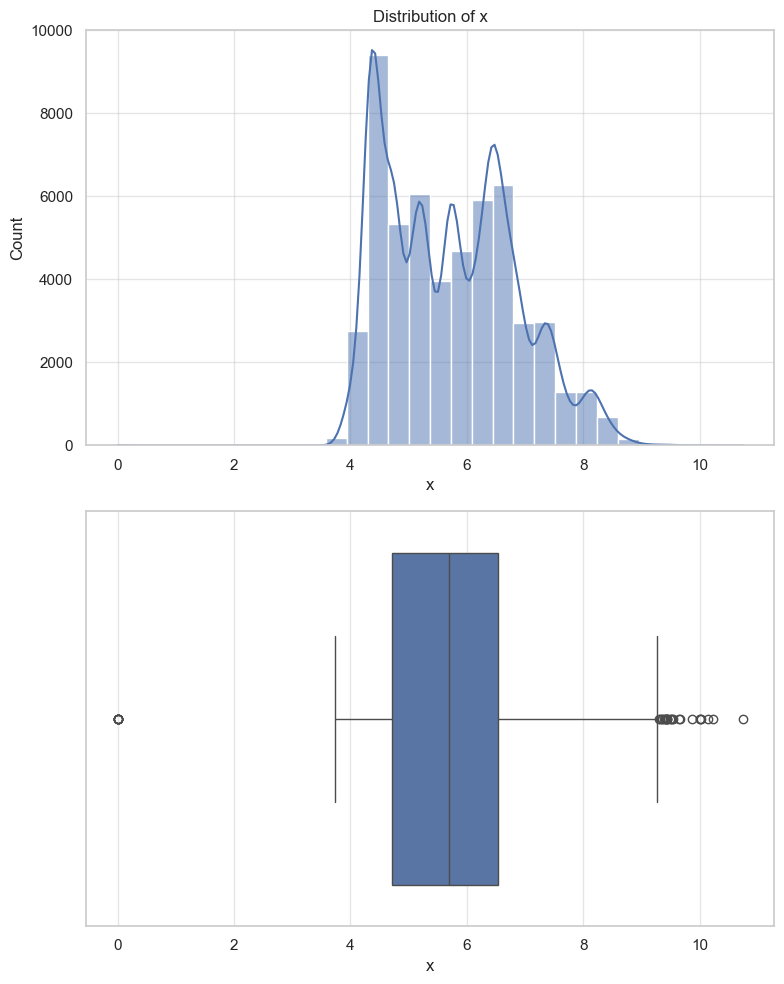

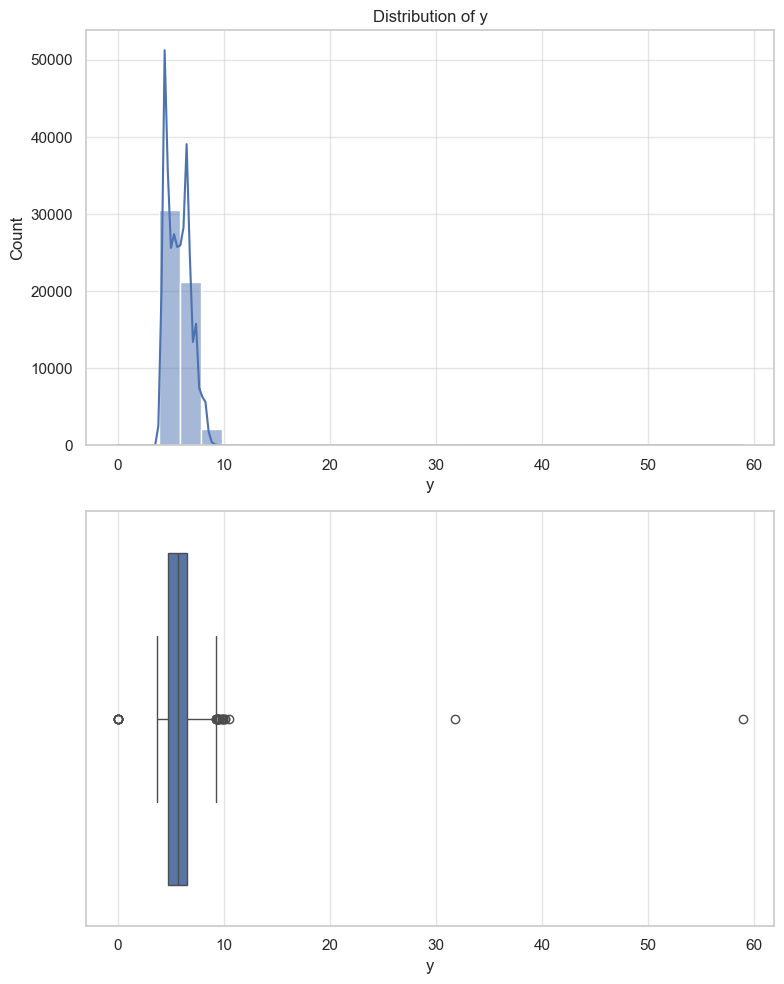

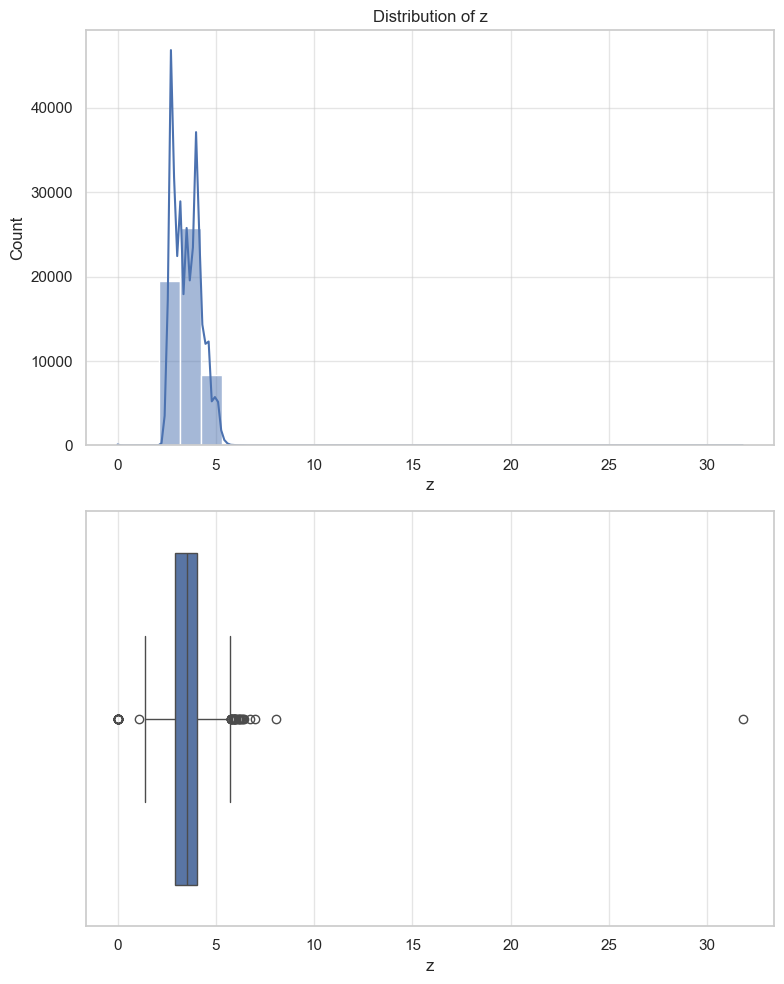

In [12]:
numeric_df = df.select_dtypes(include=[np.number])

for coluna in numeric_df.columns:
    plt.figure(figsize=(8, 10))

    plt.subplot(2, 1, 1)
    sns.histplot(data=numeric_df, x=coluna, kde=True, bins=30)
    plt.title(f"Distribution of {coluna}")

    plt.subplot(2, 1, 2)
    sns.boxplot(data=numeric_df, x=coluna)

    plt.tight_layout()
    plt.show()

## 5. Categorical Variable Quality
We analyse cardinality, frequency concentration, and rare levels to assess the behaviour of categorical features.



In [13]:
def categorical_quality_report(df, rare_threshold=0.05):
    results = []

    for col in df.select_dtypes(exclude="number").columns:
        s = df[col]
        rel_freq = s.value_counts(normalize=True, dropna=True)

        cardinality = s.nunique(dropna=True)
        dominant_pct = rel_freq.max() * 100
        rare_levels = rel_freq[rel_freq < rare_threshold]

        score = 0
        if dominant_pct > 80:
            score += 1
        if len(rare_levels) > 3:
            score += 1
        if cardinality > 30:
            score += 1

        overall_quality = (
            "High Quality"              if score == 0 else
            "Moderate Quality"          if score == 1 else
            "Statistically Challenging"
        )

        results.append({
            "variable"         : col,
            "cardinality"      : cardinality,
            "cardinality_level": "Low" if cardinality < 10 else ("Moderate" if cardinality <= 30 else "High"),
            "dominant_pct"     : round(dominant_pct, 2),
            "rare_levels"      : len(rare_levels),
            "rare_pct"         : round(rare_levels.sum() * 100, 2),
            "imbalance"        : (
                "Balanced"           if dominant_pct < 60 else
                "Moderate imbalance" if dominant_pct < 80 else
                "High imbalance"
            ),
            "overall_quality"  : overall_quality
        })

    return pd.DataFrame(results)



### Categorical Profile Interpretation
Highly imbalanced categories or those with high cardinality tend to require careful encoding and may introduce noise if handled poorly.



In [14]:
categorical_report = categorical_quality_report(df)
print(categorical_report)

  variable  cardinality cardinality_level  dominant_pct  rare_levels  rare_pct imbalance overall_quality
0      cut            5               Low         39.95            1      2.98  Balanced    High Quality
1    color            7               Low         20.93            0      0.00  Balanced    High Quality
2  clarity            8               Low         24.22            2      4.69  Balanced    High Quality


## 6. Relationship with Target `price`
Correlation and scatter plots help identify which variables have the greatest explanatory power over price.



In [15]:
corr_pearson = df.corr(numeric_only=True)
corr_target_pearson = corr_pearson['price'].sort_values(ascending=False)
corr_target_pearson

price    1.000000
carat    0.921591
x        0.884433
y        0.865419
z        0.861249
table    0.127118
depth   -0.010630
Name: price, dtype: float64

### Pearson Correlation Matrix — Interpretation

**Key readings:**

- **price × carat = 0.92** — price grows strongly with diamond weight (carats).
- **price × x = 0.88, price × y = 0.87, price × z = 0.86** — physical dimensions are also well correlated with price.
- **carat × x = 0.98** and **x × y / x × z / y × z ≈ 0.95–0.97** — the geometric measurements are highly correlated with each other and with carat, indicating strong collinearity.

**Practical implication:** `carat` and the physical dimensions carry almost the same information (high redundancy). This multicollinearity should be taken into account in linear models, where redundant features can destabilise coefficient estimates.



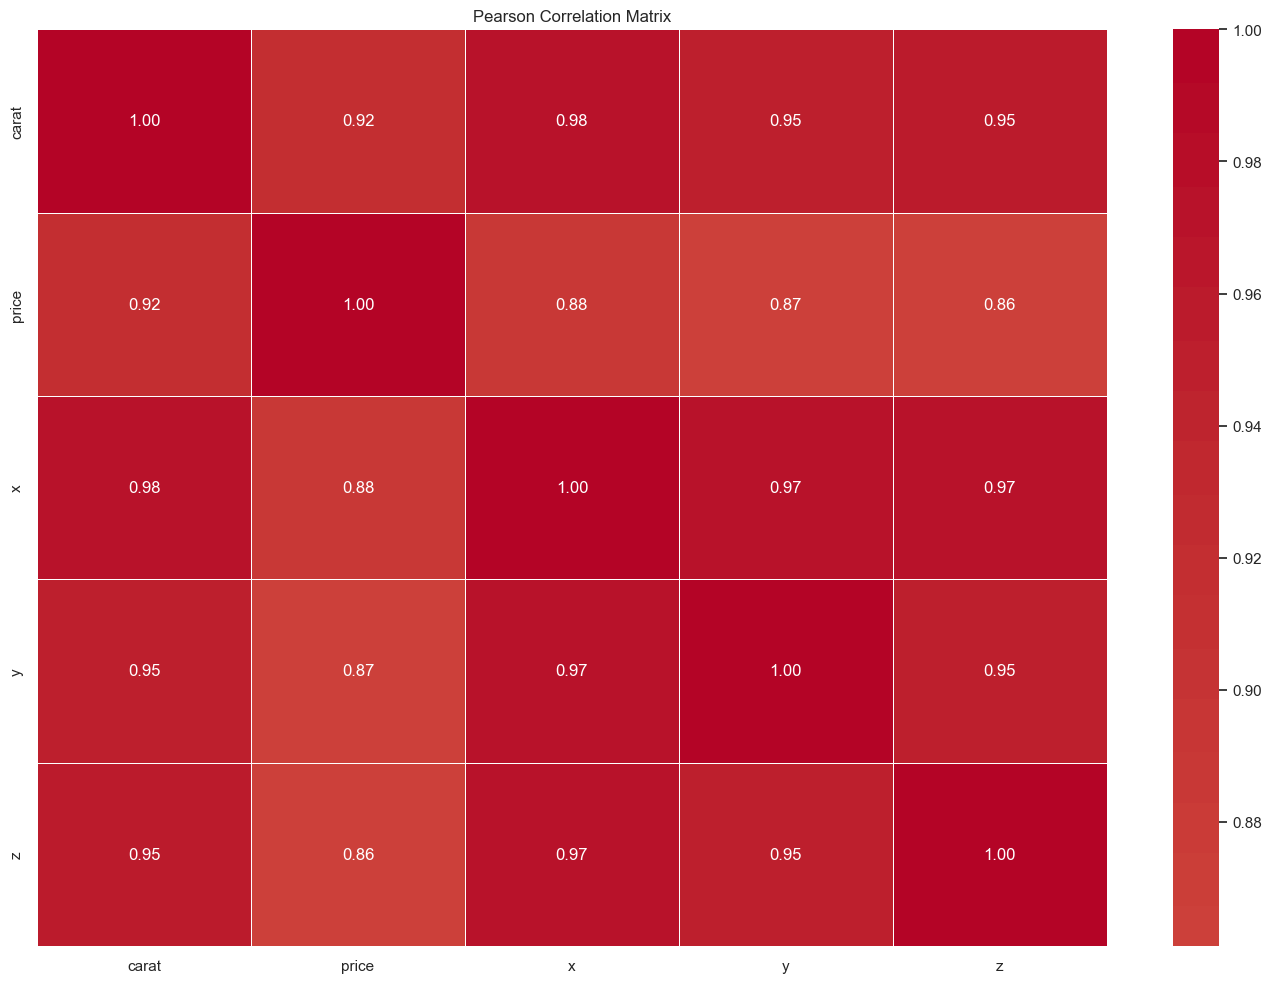

In [16]:
high_corr_cols = corr_pearson.index[corr_pearson['price'].abs() > 0.3].tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_pearson.loc[high_corr_cols, high_corr_cols],
    cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

### Scatter Plots — Interpretation

Each plot shows a numeric predictor against `price`, with the Pearson correlation coefficient *r* in the title.

- **carat vs price (r = 0.92):** Clearly increasing trend. Vertical bands appear at round carat values (0.5, 1.0, 1.5, 2.0), and variance expands for larger carats — a sign of heteroscedasticity.
- **x vs price (r = 0.88), y vs price (r = 0.87), z vs price (r = 0.86):** Strong positive relationships; larger stones tend to cost more. A few outliers are visible — extreme y or z values may indicate data entry errors or genuine rarities.
- **table vs price (r = 0.13):** Very weak correlation; `table` alone explains almost none of the price variance.
- **depth vs price (r = −0.01):** Effectively zero linear relationship; `depth` provides no direct linear signal for price in isolation.



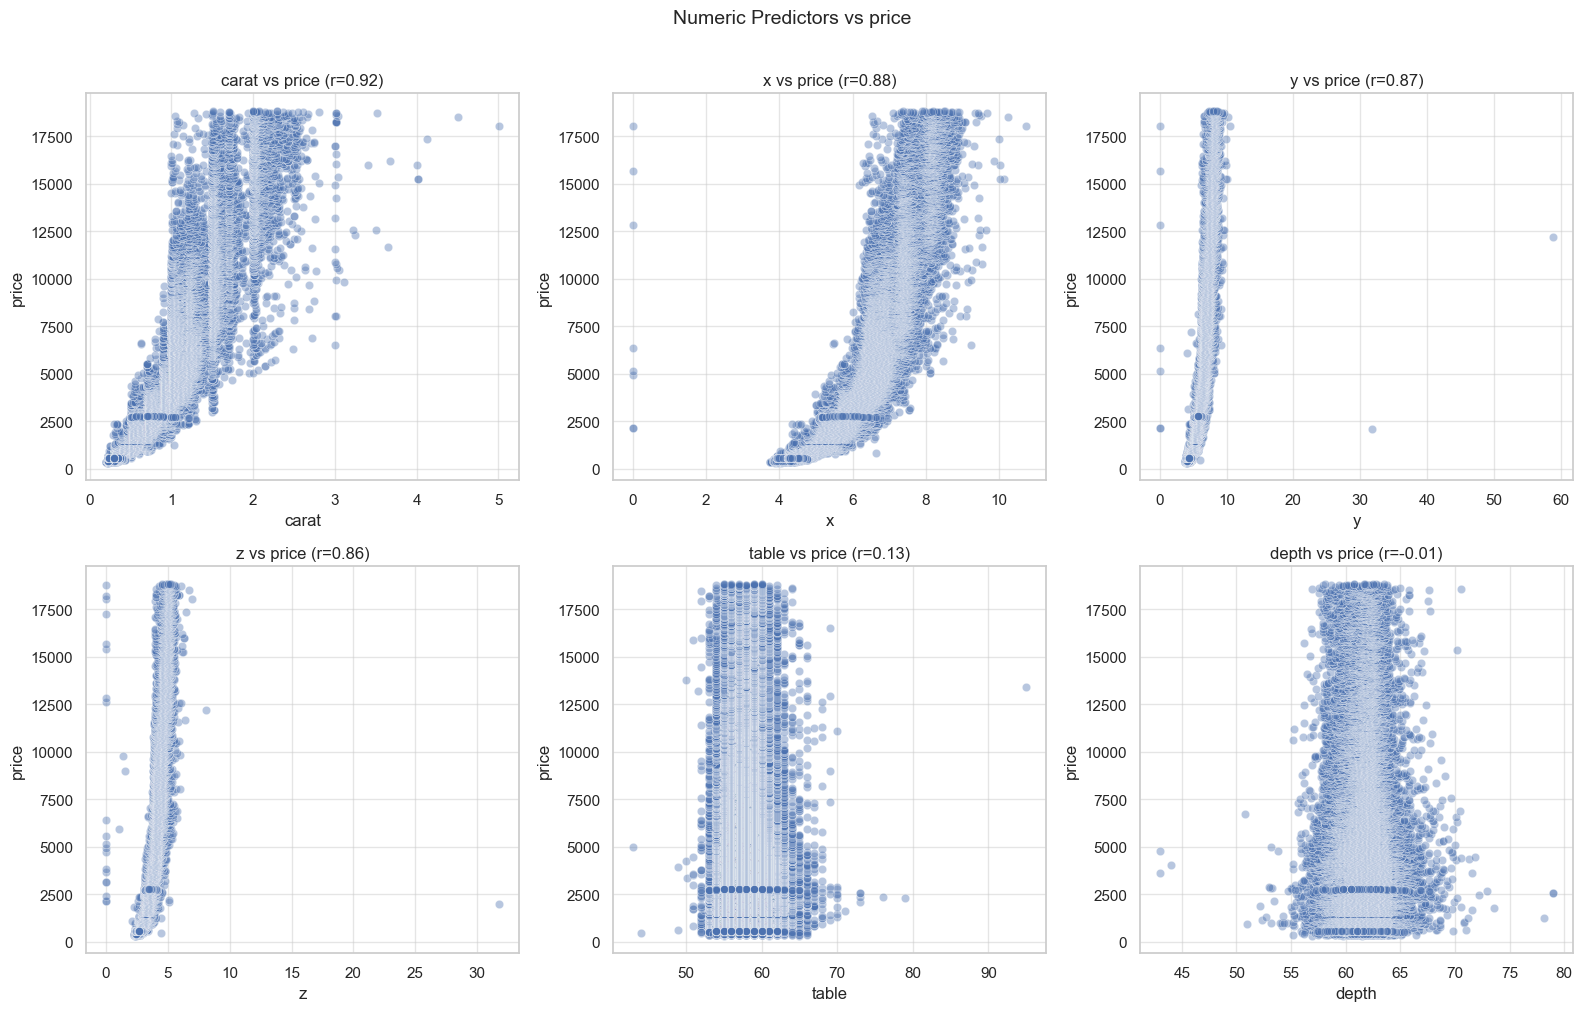

In [17]:
top_predictors = corr_target_pearson.drop('price').abs().sort_values(ascending=False).index.tolist()
n = len(top_predictors)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5))
axes = np.atleast_1d(axes).flatten()
for i, col in enumerate(top_predictors):
    sns.scatterplot(data=df, x=col, y='price', alpha=0.4, ax=axes[i])
    axes[i].set_title(f"{col} vs price (r={corr_target_pearson[col]:.2f})")
for j in range(len(top_predictors), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Numeric Predictors vs price", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 7. Price Distribution
Before modelling, it is worth verifying whether the target is approximately symmetric or has a long right tail.

**Price histogram (raw):** The distribution is strongly right-skewed — most diamonds are priced in the lower range, with a long tail of expensive outliers. This is common for price variables and suggests that the raw target may not satisfy the normality assumptions of OLS regression.



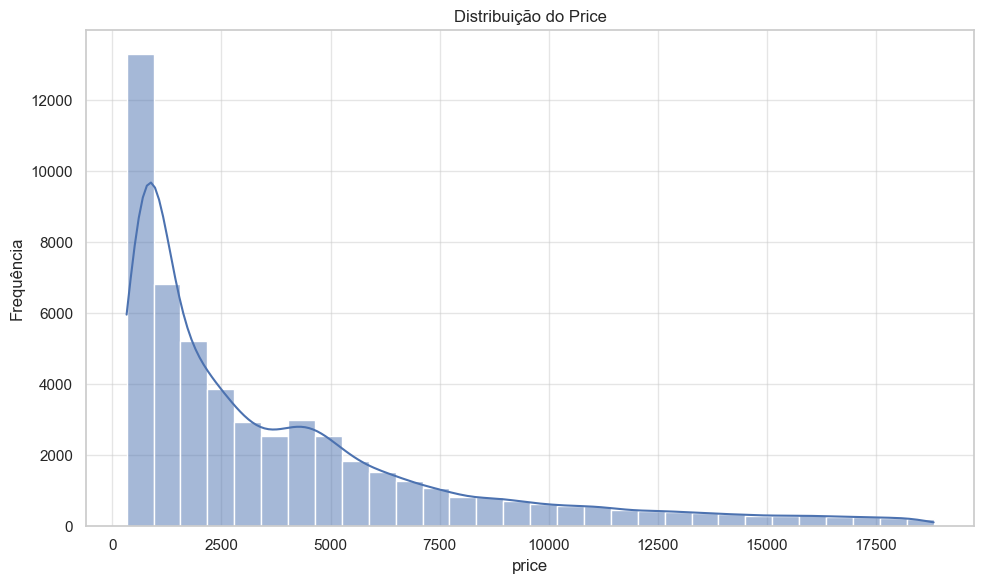

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribuição do Price')
plt.xlabel('price')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### Log-Transformation — Interpretation

Applying a logarithm to `price` produces a distribution that is markedly more symmetric and bell-shaped compared to the raw values. The transformation achieves three practical benefits:

1. **Reduces the influence of extreme values** — very expensive diamonds no longer dominate residuals.
2. **Captures multiplicative relationships** — if price grows proportionally with predictors, `log(price)` linearises that relationship.
3. **Stabilises variance** — heteroscedasticity is reduced, improving the reliability of OLS coefficient estimates.

Using `log(price)` as the modelling target is therefore strongly recommended.



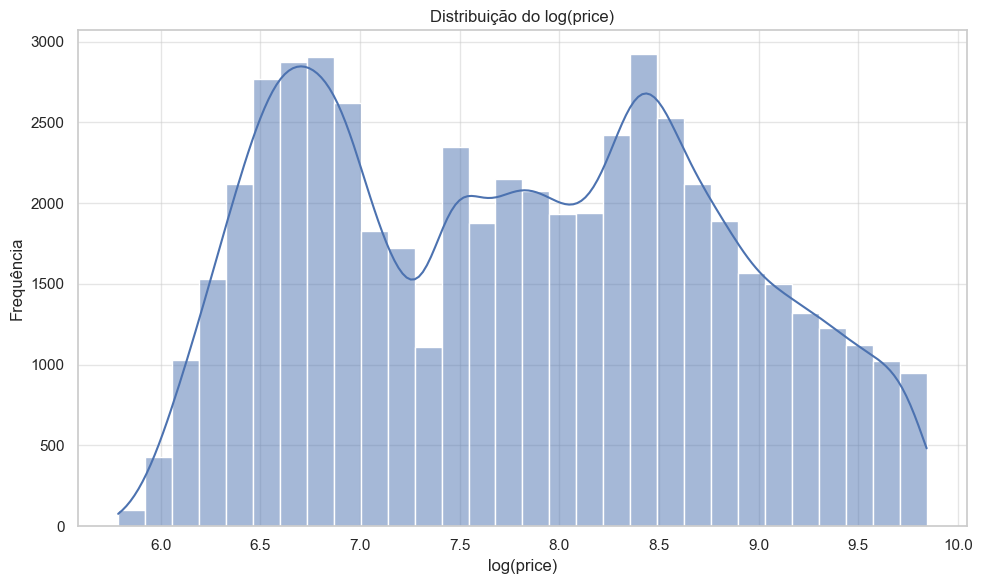

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log(df['price']), bins=30, kde=True)
plt.title('Distribuição do log(price)')
plt.xlabel('log(price)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

## 8. Consistency Checks
Zeros in geometric dimensions, duplicate rows, and other implausible values are important signals of data quality issues.

In [20]:
for col in ['x', 'y', 'z']:
    n_zero = (df[col] == 0).sum()
    print(f"{col}: {n_zero} zeros")

x: 8 zeros
y: 7 zeros
z: 20 zeros


In [21]:
df_zero = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
display(df_zero.head(10))


,carat,cut,color,clarity,depth,table,price,x,y,z
2208,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2315,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4792,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5472,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10168,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11183,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11964,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13602,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15952,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24395,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


## 9. Outliers
IQR-based inspection identifies extreme values that may affect model fit, correlations, and regression coefficients.



In [22]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_price = df[(df['price'] < lower) | (df['price'] > upper)]
print("Outliers (IQR) in price:", len(outliers_price))
display(outliers_price.sort_values('price', ascending=False).head(10))

Outliers (IQR) in price: 3540


,carat,cut,color,clarity,depth,table,price,x,y,z
27750,2.29,Premium,I,VS2,60.8,60.0,18823,8.50,8.47,5.16
27749,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04
27748,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56
27747,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11
27746,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01
27745,2.29,Premium,I,SI1,61.8,59.0,18797,8.52,8.45,5.24
27743,2.04,Premium,H,SI1,58.1,60.0,18795,8.37,8.28,4.84
27744,2.00,Premium,I,VS1,60.8,59.0,18795,8.13,8.02,4.91
27742,2.15,Ideal,G,SI2,62.6,54.0,18791,8.29,8.35,5.21
27741,1.71,Premium,F,VS2,62.3,59.0,18791,7.57,7.53,4.70


### Outliers — Interpretation
Outliers are not necessarily errors, but they warrant investigation to decide between treatment, transformation, or controlled retention.



## 10. Multicollinearity
VIF measures redundancy among related numeric variables and helps identify instability in linear models.



In [23]:
X_vif_phys = df[['x', 'y', 'z', 'depth', 'table']].dropna()
Xc_phys = sm.add_constant(X_vif_phys)
vif_phys = pd.Series(
    [variance_inflation_factor(Xc_phys.values, i) for i in range(Xc_phys.shape[1])],
    index=Xc_phys.columns
)
vif_phys

const    4083.072250
x          37.193868
y          20.433109
z          23.529001
depth       1.432490
table       1.141932
dtype: float64

### Physical VIF — Interpretation
High VIF values indicate strong overlap among geometric variables and signal the risk of unstable coefficients in linear regression.



## 11. Pearson vs Spearman
Comparing Pearson and Spearman helps separate linear correlation from monotonic association, which is useful when data are skewed or contain outliers.



In [24]:
corr_spearman = df.corr(method='spearman', numeric_only=True)
corr_target_spearman = corr_spearman['price'].sort_values(ascending=False)

comparison = pd.DataFrame({
    'Pearson': corr_target_pearson,
    'Spearman': corr_target_spearman
}).dropna().sort_values('Spearman', ascending=False)

comparison.head(20)

,Pearson,Spearman
price,1.000000,1.000000
x,0.884433,0.963199
carat,0.921591,0.962886
y,0.865419,0.962722
z,0.861249,0.957235
table,0.127118,0.171781
depth,-0.010630,0.010009


### Correlation Comparison — Interpretation
Differences between Pearson and Spearman typically indicate non-linear relationships or a meaningful impact of extreme values.



## 12. Low-Cardinality Categorical Variables
Boxplots allow us to verify whether categories explain meaningful price differences and whether there is visual separation between groups.

**price by cut:** Distributions overlap considerably across cut grades (Ideal, Premium, Good, Very Good, Fair). Cut alone does not produce clean price separation — `carat` tends to dominate price, so different cut grades can show similar prices when stone sizes vary. Many high-price outliers appear across all categories.

**price by color:** Strong overlap across colour grades (D–J). Some categories show higher medians, but the effect is modest compared to the carat–price relationship. A correct interpretation requires controlling for carat (e.g., comparing colours within the same carat range).

**price by clarity:** Some median differences are visible across clarity levels, but within-category variance is large. Many high-price outliers appear even in less 'rare' clarity grades, most likely because those stones have high carat weight.



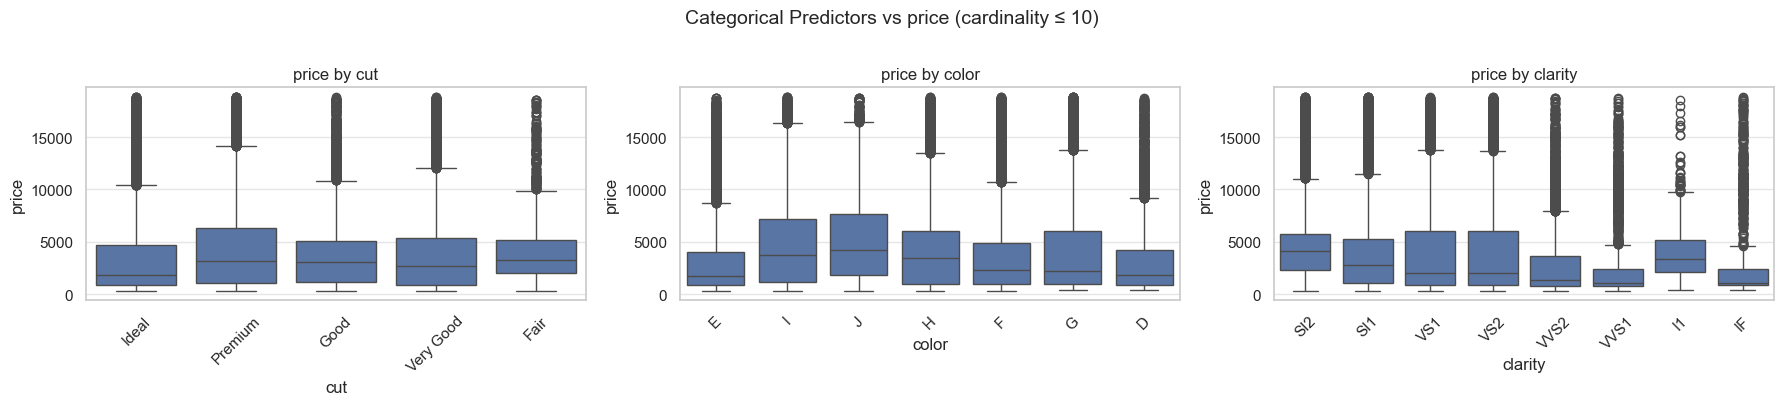

In [25]:
cat_cols_low_card = categorical_report[categorical_report['cardinality'] <= 10]['variable'].tolist()
n = len(cat_cols_low_card)
ncols = 3

if n > 0:
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols_low_card):
        sns.boxplot(data=df, x=col, y='price', ax=axes[i])
        axes[i].set_title(f"price by {col}")
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Categorical Predictors vs price (cardinality ≤ 10)", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [26]:
vif_candidates = corr_target_pearson.drop('price').abs().sort_values(ascending=False).index.tolist()

In [27]:
X_vif = df[vif_candidates].dropna()
X_vif = sm.add_constant(X_vif)

In [28]:
vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False)

,variable,VIF
2,x,56.187020
4,z,23.530057
1,carat,21.602141
3,y,20.454259
6,depth,1.496646
5,table,1.143233


### General VIF — Interpretation
When VIF values are very high, the predictor set should be revisited — removing redundant features or applying regularisation are the typical remedies.



## 13. Association Between Categorical Variables
Cramér's V measures dependence between categorical pairs and highlights structural redundancies among nominal variables.



In [29]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    n = table.sum().sum()
    k = min(table.shape)
    if k <= 1:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table)
    return np.sqrt(chi2 / (n * (k - 1)))


cat_cols_for_cramers = categorical_report[categorical_report['cardinality'] <= 15]['variable'].tolist()

pairs = []
for i, col1 in enumerate(cat_cols_for_cramers):
    for col2 in cat_cols_for_cramers[i+1:]:
        value = cramers_v(df[col1], df[col2])
        if not np.isnan(value):
            pairs.append({'var1': col1, 'var2': col2, 'cramers_v': round(value, 3)})

pd.DataFrame(pairs).sort_values('cramers_v', ascending=False).head(20)

,var1,var2,cramers_v
1,cut,clarity,0.143
2,color,clarity,0.080
0,cut,color,0.038


### Notebook Conclusion
`carat` is the strongest single signal for `price`, while the geometric variables (`x`, `y`, `z`) provide largely redundant information and raise multicollinearity concerns in linear models. Key next steps: remove or impute zero-dimension rows, decide on duplicate treatment, apply `log(price)` as the modelling target, and reduce geometric redundancy through feature selection or dimensionality reduction before modelling.

